<a href="https://colab.research.google.com/github/Nitin22122/DL-Lab/blob/main/Time_Series_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

In [ ]:
stock = "RELIANCE.NS"
df = yf.download(stock, start="2020-01-01", end="2026-02-26")

data = df[['Close']]

/tmp/ipython-input-681/3324181274.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2020-01-01", end="2026-02-26")
[*********************100%***********************]  1 of 1 completed


In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [ ]:
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, 60)

X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(50))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.1152
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0376
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0326
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0200
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0158
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0127
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0109
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0092
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0094
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0081
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0071
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0078
Epoch 13/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0060
Epoch 14/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0062
Epoch 15/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0051
Epoch 

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


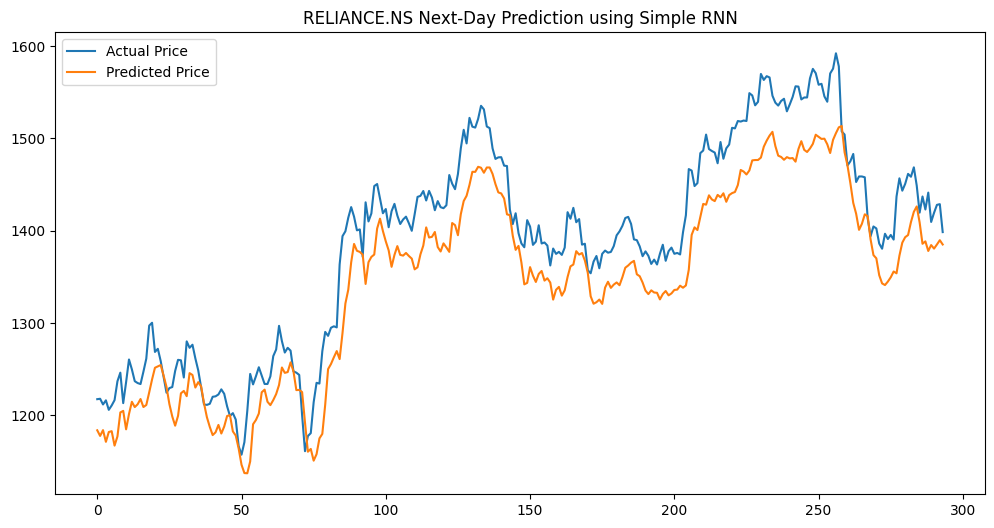

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title(f"{stock} Next-Day Prediction using Simple RNN")
plt.legend()
plt.show()

In [ ]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1,60,1)

tomorrow_price = model.predict(last_60_days)
tomorrow_price = scaler.inverse_transform(tomorrow_price)

print("Predicted Next Day Price:", tomorrow_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
Predicted Next Day Price: 1370.293
